Загружаем SBER...
Загружаем IMOEX...
Загружаем USD/RUB (USD000UTSTOM)...
Число строк после очистки: 2982
X_train: (1769, 20, 12) y_train: (1769, 1)
X_test: (1173, 20, 12) y_test: (1173, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 150)        │        97,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20, 64)         │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_1               │ (None, 64)             │            84 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,997 (554.68 KB)

 Trainable params: 141,997 (554.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0221 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0047 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0037 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0030 - val_loss: 0.0023 - learning_rate: 0.0010
E

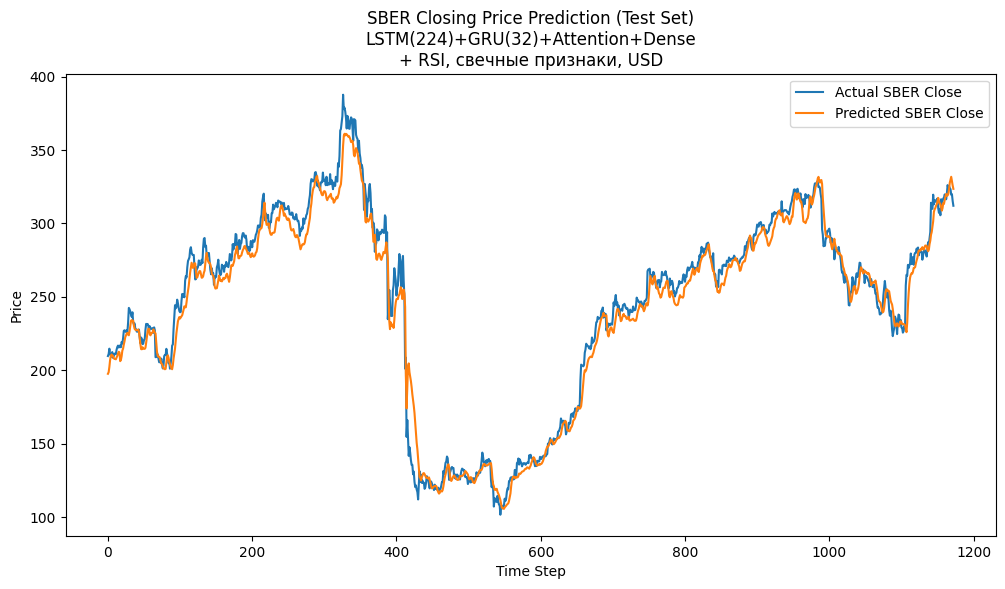

In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error

# ============================================================
# Функция для загрузки данных с MOEX
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100

    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break

    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

# ============================================================
# Функция для расчёта RSI
# ============================================================
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ============================================================
# Функция для предобработки данных для FastAPI
# ============================================================
def preprocess_data(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    # Приводим дату к datetime, сортируем и сбрасываем индекс
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Переименование столбцов с добавлением тикера
    ticker = ticker.upper()
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col, 
        "OPEN": open_col, 
        "HIGH": high_col, 
        "LOW": low_col, 
        "VOLUME": vol_col
    }, inplace=True)
    
    # Вычисляем RSI
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    df.dropna(subset=[rsi_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Вычисляем свечные признаки:
    # BODY: абсолютная разница между CLOSE и OPEN
    body_col = f"BODY_{ticker}"
    df[body_col] = (df[close_col] - df[open_col]).abs()
    
    # UPPER_SHADOW: разница между HIGH и максимумом из (OPEN, CLOSE)
    upper_shadow_col = f"UPPER_SHADOW_{ticker}"
    df[upper_shadow_col] = df[high_col] - df[[open_col, close_col]].max(axis=1)
    
    # LOWER_SHADOW: разница между минимумом из (OPEN, CLOSE) и LOW
    lower_shadow_col = f"LOWER_SHADOW_{ticker}"
    df[lower_shadow_col] = df[[open_col, close_col]].min(axis=1) - df[low_col]
    
    # Дополнительный признак: VOLATILITY (7-дневное скользящее стандартное отклонение цены закрытия)
    volatility_col = f"VOLATILITY_{ticker}"
    df[volatility_col] = df[close_col].rolling(window=7).std()
    df.dropna(subset=[volatility_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

# ============================================================
# Кастомный слой внимания (Attention)
# ============================================================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(name='att_weight', shape=(hidden_dim, 1), initializer='glorot_uniform')
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1), initializer='zeros')
        super().build(input_shape)
    
    def call(self, inputs):
        e = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

# ============================================================
# Основной скрипт для обучения модели
# ============================================================
if __name__ == "__main__":
    # 1. Параметры
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    ticker = "SBER"
    
    # 2. Загрузка данных для тикера
    print(f"Загружаем {ticker}...")
    df_ticker = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    
    print("Загружаем IMOEX...")
    df_imoex = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    
    print("Загружаем USD/RUB (USD000UTSTOM)...")
    df_usd = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if df_ticker is None or df_imoex is None or df_usd is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    # Предобработка данных для тикера
    df_ticker_processed = preprocess_data(df_ticker, ticker=ticker)
    
    # Предобработка данных для других источников (оставляем как есть)
    df_imoex["TRADEDATE"] = pd.to_datetime(df_imoex["TRADEDATE"])
    df_imoex.sort_values("TRADEDATE", inplace=True)
    df_imoex.reset_index(drop=True, inplace=True)
    
    df_usd["TRADEDATE"] = pd.to_datetime(df_usd["TRADEDATE"])
    df_usd.sort_values("TRADEDATE", inplace=True)
    df_usd.reset_index(drop=True, inplace=True)
    
    # Объединяем данные по дате
    merged_df = df_ticker_processed.merge(
        df_imoex[["TRADEDATE", "CLOSE"]].rename(columns={"CLOSE": "CLOSE_IMOEX"}),
        on="TRADEDATE", how="outer")
    merged_df = merged_df.merge(
        df_usd[["TRADEDATE", "CLOSE"]].rename(columns={"CLOSE": "CLOSE_USD"}),
        on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    # Удаляем строки с пропусками по ключевым признакам
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    print(f"Число строк после очистки: {len(merged_df)}")
    
    # 3. Формирование признаков для FastAPI
    # Ожидается, что признаки начинаются с: OPEN, HIGH, LOW, CLOSE, VOL, RSI, BODY, UPPER_SHADOW, LOWER_SHADOW.
    # В нашем случае после preprocess_data для SBER получаем:
    # OPEN_SBER, HIGH_SBER, LOW_SBER, CLOSE_SBER, VOL_SBER, RSI_SBER, BODY_SBER, UPPER_SHADOW_SBER, LOWER_SHADOW_SBER, VOLATILITY_SBER
    features = [col for col in merged_df.columns if col.startswith(("OPEN", "HIGH", "LOW", "CLOSE", "VOL", "RSI", "BODY", "UPPER_SHADOW", "LOWER_SHADOW"))]
    target_cols = [f"CLOSE_{ticker}"]
    
    data = merged_df[features].values.astype(float)
    targets = merged_df[target_cols].values.astype(float)
    
    # 4. Разбиение на обучающую и тестовую выборки
    total_len = len(data)
    train_end = int(0.6 * total_len)
    train_data = data[:train_end]
    test_data  = data[train_end:]
    train_targets = targets[:train_end]
    test_targets  = targets[train_end:]
    
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    # Функция формирования последовательностей (window length = 20)
    def create_sequences(X, y, seq_length=20):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i + seq_length])
        return np.array(X_seq), np.array(y_seq)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    # Ожидаемая форма: (None, 20, 10) (10 признаков)
    
    # 5. Построение модели (пример: LSTM + GRU + Attention + Dense)
    input_layer = Input(shape=(seq_length, len(features)))
    
    x = LSTM(150, return_sequences=True)(input_layer)
    x = Dropout(0.1)(x)
    
    x = GRU(64, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    
    x = AttentionLayer()(x)
    
    x = Dense(40, activation="relu")(x)
    x = Dropout(0.15)(x)
    
    output_layer = Dense(1)(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer="Nadam", loss="mse")
    model.summary()
    
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_train, y_train,
        epochs=40,
        batch_size=16,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )
    
    # 6. Оценка модели и визуализация результатов
    test_loss = model.evaluate(X_test, y_test, verbose=1)
    print("Test Loss (MSE):", test_loss)
    
    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    actuals = scaler_y.inverse_transform(y_test)
    
    mse_orig = mean_squared_error(actuals, preds)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals - preds))
    mape_orig = np.mean(np.abs((actuals - preds) / actuals)) * 100
    
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual SBER Close")
    plt.plot(preds, label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nLSTM(224)+GRU(32)+Attention+Dense\n+ RSI, свечные признаки, USD")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_orig = mean_squared_error(actuals, preds)
mae_orig = mean_absolute_error(actuals, preds)
rmse_orig = np.sqrt(mse_orig)

print(f"MSE (original scale, рубли^2): {mse_orig:.4f}")
print(f"RMSE (original scale, рубли):  {rmse_orig:.4f}")
print(f"MAE (original scale, рубли):   {mae_orig:.4f}")

mape = np.mean(np.abs(actuals - preds) / actuals) * 100
print(f"MAPE: {mape:.2f}%")

MSE (original scale, рубли^2): 51.9321
RMSE (original scale, рубли):  7.2064
MAE (original scale, рубли):   5.0228
MAPE: 2.20%


In [2]:
import pickle
import os

# Создаем папку для сохранения, если её нет
os.makedirs("../models", exist_ok=True)

ticker = "SBER"

# Определяем пути сохранения (используем нативный формат Keras)
model_save_path = f"../models/{ticker}_final_model.keras"
scaler_X_path = f"../models/{ticker}_scaler_X.pkl"
scaler_y_path = f"../models/{ticker}_scaler_y.pkl"

# Сохраняем модель
model.save(model_save_path)

# Сохраняем скейлеры
with open(scaler_X_path, "wb") as f:
    pickle.dump(scaler_X, f)
with open(scaler_y_path, "wb") as f:
    pickle.dump(scaler_y, f)

print(f"Модель и скейлеры для {ticker} успешно сохранены.")


Модель и скейлеры для SBER успешно сохранены.


# Pytorch version

Загружаем данные SBER с MOEX...
Загружаем IMOEX...
Загружаем USD/RUB...
Число строк после очистки: 3010
X_train: (1786, 20, 8) y_train: (1786, 1)
X_test: (1184, 20, 8) y_test: (1184, 1)
Epoch 1/60 - Loss: 0.0174 - Val Loss: 0.0072
Epoch 2/60 - Loss: 0.0032 - Val Loss: 0.0082
Epoch 3/60 - Loss: 0.0025 - Val Loss: 0.0071
Epoch 4/60 - Loss: 0.0025 - Val Loss: 0.0082
Epoch 5/60 - Loss: 0.0027 - Val Loss: 0.0049
Epoch 6/60 - Loss: 0.0024 - Val Loss: 0.0069
Epoch 7/60 - Loss: 0.0023 - Val Loss: 0.0093
Epoch 8/60 - Loss: 0.0019 - Val Loss: 0.0048
Epoch 9/60 - Loss: 0.0021 - Val Loss: 0.0031
Epoch 10/60 - Loss: 0.0019 - Val Loss: 0.0027
Epoch 11/60 - Loss: 0.0017 - Val Loss: 0.0035
Epoch 12/60 - Loss: 0.0016 - Val Loss: 0.0058
Epoch 13/60 - Loss: 0.0016 - Val Loss: 0.0025
Epoch 14/60 - Loss: 0.0015 - Val Loss: 0.0014
Epoch 15/60 - Loss: 0.0015 - Val Loss: 0.0034
Epoch 16/60 - Loss: 0.0014 - Val Loss: 0.0036
Epoch 17/60 - Loss: 0.0015 - Val Loss: 0.0029
Epoch 18/60 - Loss: 0.0014 - Val Loss: 0.

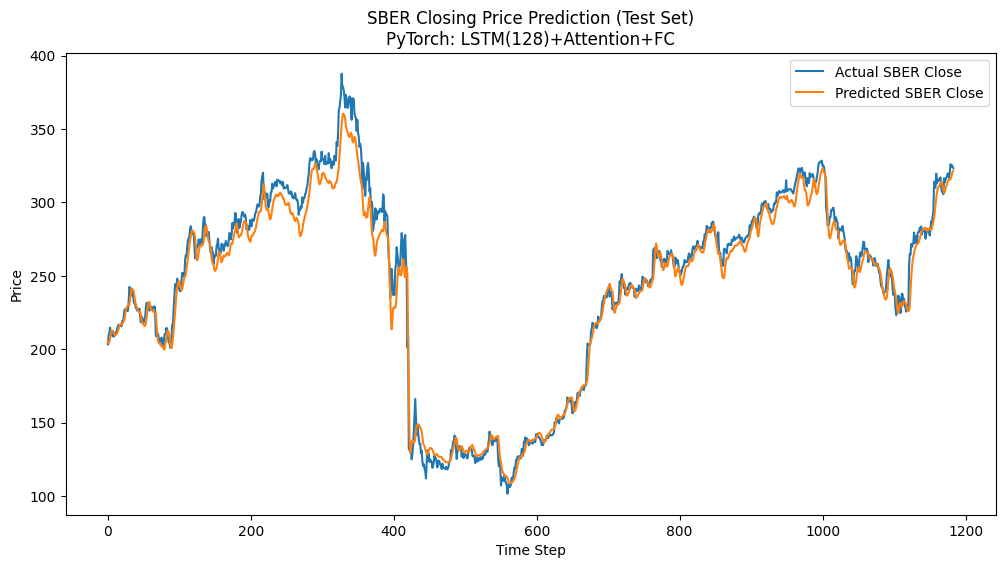

In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# 1. Функции для загрузки данных и предобработки
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def preprocess_data(df, ticker):
    # Приведение даты к datetime и сортировка
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Переименование столбцов для уникальности
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col,
        "OPEN": open_col,
        "HIGH": high_col,
        "LOW": low_col,
        "VOLUME": vol_col
    }, inplace=True)
    
    # Вычисление RSI для цены закрытия
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    df.dropna(subset=[rsi_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# 2. Определение модели на PyTorch
# ============================================================
class AttentionLayer(nn.Module):
    """
    Кастомный слой внимания.
    Принимает вход размером (batch, timesteps, hidden_dim) и возвращает вектор (batch, hidden_dim)
    """
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        # e = x @ W + b -> (batch, timesteps, 1)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha  # (batch, timesteps, hidden_dim)
        context = torch.sum(context, dim=1)  # (batch, hidden_dim)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        # Attention: timesteps = seq_length, hidden_dim = lstm_units
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        # x: (batch, seq_length, num_features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_length, lstm_units)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)  # (batch, lstm_units)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ============================================================
# 3. Основной скрипт для тикера SBER
# ============================================================
if __name__ == "__main__":
    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER", "OPEN": "OPEN_SBER", "HIGH": "HIGH_SBER", "LOW": "LOW_SBER", "VOLUME": "VOL_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df   = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer").merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    merged_df["RSI_SBER"] = compute_rsi(merged_df["CLOSE_SBER"], period=14)
    merged_df.dropna(subset=["RSI_SBER"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    print(f"Число строк после очистки: {len(merged_df)}")
    
    # Формирование признаков и целевой переменной
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER"]
    target_col = "CLOSE_SBER"
    
    data = merged_df[features].values.astype(float)
    targets = merged_df[[target_col]].values.astype(float)
    
    # Разбивка на train/test (60% train, 40% test)
    total_len = len(data)
    train_end = int(0.6 * total_len)
    train_data = data[:train_end]
    test_data = data[train_end:]
    train_targets = targets[:train_end]
    test_targets = targets[train_end:]
    
    # Масштабирование данных
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    # Формирование скользящих окон (последовательностей)
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    
    # Преобразуем в тензоры и создаем DataLoader
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # Параметры модели
    device = torch.device("mps" if torch.mps.is_available() else "cpu")
    model_pt = PricePredictionModel(seq_length, len(features), output_dim=1,
                                    lstm_units=150, fc_units=64, dropout_rate=0.1)
    model_pt.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model_pt.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    # Тренировочный цикл с ранней остановкой и градиентным клиппингом
    num_epochs = 60
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model_pt.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_pt.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model_pt.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model_pt(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model_pt.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break

    model_pt.load_state_dict(best_model_state)
    
    # Оценка модели
    model_pt.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    # Обратное масштабирование
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"Метрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM(128)+Attention+FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


Загружаем данные SBER с MOEX...
Загружаем IMOEX...
Загружаем USD/RUB...
Число строк после очистки: 2975
X_train: (2360, 20, 9) y_train: (2360, 1)
X_test: (575, 20, 9) y_test: (575, 1)
Epoch 1/40 - Loss: 0.0139 - Val Loss: 0.0116
Epoch 2/40 - Loss: 0.0031 - Val Loss: 0.0028
Epoch 3/40 - Loss: 0.0030 - Val Loss: 0.0030
Epoch 4/40 - Loss: 0.0023 - Val Loss: 0.0027
Epoch 5/40 - Loss: 0.0021 - Val Loss: 0.0038
Epoch 6/40 - Loss: 0.0019 - Val Loss: 0.0042
Epoch 7/40 - Loss: 0.0019 - Val Loss: 0.0043
Epoch 8/40 - Loss: 0.0016 - Val Loss: 0.0043
Epoch 9/40 - Loss: 0.0014 - Val Loss: 0.0036
Epoch 10/40 - Loss: 0.0015 - Val Loss: 0.0051
Epoch 11/40 - Loss: 0.0013 - Val Loss: 0.0031
Epoch 12/40 - Loss: 0.0012 - Val Loss: 0.0024
Epoch 13/40 - Loss: 0.0011 - Val Loss: 0.0024
Epoch 14/40 - Loss: 0.0011 - Val Loss: 0.0022
Epoch 15/40 - Loss: 0.0011 - Val Loss: 0.0021
Epoch 16/40 - Loss: 0.0011 - Val Loss: 0.0026
Epoch 17/40 - Loss: 0.0011 - Val Loss: 0.0020
Epoch 18/40 - Loss: 0.0011 - Val Loss: 0.00

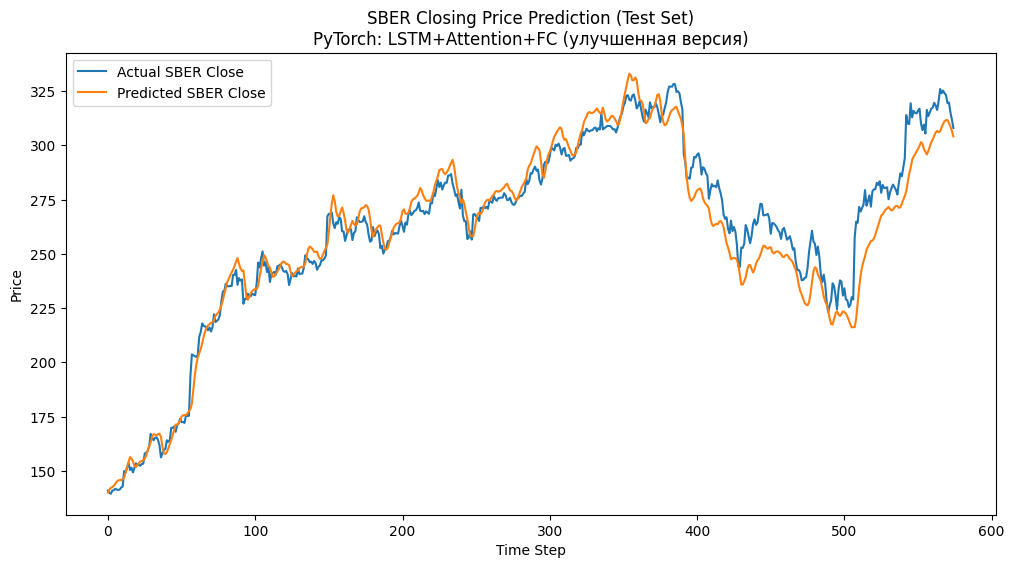

In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# 1. Функции для загрузки данных и предобработки
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_sma(series: pd.Series, window: int = 14) -> pd.Series:
    """Вычисляет простую скользящую среднюю (SMA)."""
    return series.rolling(window=window).mean()

def preprocess_data(df, ticker):
    # Приведение даты к datetime и сортировка
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Переименование столбцов для уникальности
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col,
        "OPEN": open_col,
        "HIGH": high_col,
        "LOW": low_col,
        "VOLUME": vol_col
    }, inplace=True)
    
    # Вычисление RSI для цены закрытия
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    
    # Вычисление SMA для цены закрытия
    sma_col = f"SMA_{ticker}"
    df[sma_col] = compute_sma(df[close_col], window=14)
    
    # Удаляем строки с NaN значениями индикаторов
    df.dropna(subset=[rsi_col, sma_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# 2. Определение модели на PyTorch
# ============================================================
class AttentionLayer(nn.Module):
    """
    Кастомный слой внимания.
    Принимает вход размером (batch, timesteps, hidden_dim) и возвращает вектор (batch, hidden_dim)
    """
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha  # (batch, timesteps, hidden_dim)
        context = torch.sum(context, dim=1)  # (batch, hidden_dim)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        # Attention: timesteps = seq_length, hidden_dim = lstm_units
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        # x: (batch, seq_length, num_features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_length, lstm_units)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)  # (batch, lstm_units)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ============================================================
# 3. Основной скрипт для тикера SBER
# ============================================================
if __name__ == "__main__":
    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    # Предобработка данных
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    # Применяем предобработку с вычислением дополнительных индикаторов для SBER
    sber_df = preprocess_data(sber_df, ticker)
    
    # Для IMOEX и USD оставляем только нужные столбцы
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER", "RSI_SBER", "SMA_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df   = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    # Объединяем датасеты
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer").merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER", "SMA_SBER"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    print(f"Число строк после очистки: {len(merged_df)}")
    
    # Формирование признаков и целевой переменной
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER", "SMA_SBER"]
    target_col = "CLOSE_SBER"
    
    data = merged_df[features].values.astype(float)
    targets = merged_df[[target_col]].values.astype(float)
    
    # Разбивка на train/test (60% train, 40% test)
    total_len = len(data)
    train_end = int(0.8 * total_len)
    train_data = data[:train_end]
    test_data = data[train_end:]
    train_targets = targets[:train_end]
    test_targets = targets[train_end:]
    
    # Масштабирование данных
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    # Формирование скользящих окон (последовательностей)
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    
    # Преобразуем в тензоры и создаем DataLoader
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # Параметры модели
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    # Можно попробовать изменить гиперпараметры: например, уменьшить learning rate или увеличить dropout_rate
    model_pt = PricePredictionModel(seq_length, len(features), output_dim=1,
                                    lstm_units=150, fc_units=64, dropout_rate=0.15)
    model_pt.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model_pt.parameters(), lr=0.0008, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    # Альтернативный вариант scheduler (CosineAnnealingLR)
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    
    # Тренировочный цикл с ранней остановкой и градиентным клиппингом
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model_pt.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_pt.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model_pt.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model_pt(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model_pt.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break

    model_pt.load_state_dict(best_model_state)
    
    # Оценка модели
    model_pt.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    # Обратное масштабирование
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"Метрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM+Attention+FC (улучшенная версия)")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [ ]:
import pickle
import os

# Создаем папку для сохранения, если её нет
os.makedirs("../models", exist_ok=True)

ticker = "SBER"

# Определяем пути сохранения (используем нативный формат Keras)
model_save_path = f"../models/{ticker}_final_model.keras"
scaler_X_path = f"../models/{ticker}_scaler_X.pkl"
scaler_y_path = f"../models/{ticker}_scaler_y.pkl"

# Сохраняем модель
model.save(model_save_path)

# Сохраняем скейлеры
with open(scaler_X_path, "wb") as f:
    pickle.dump(scaler_X, f)
with open(scaler_y_path, "wb") as f:
    pickle.dump(scaler_y, f)

print(f"Модель и скейлеры для {ticker} успешно сохранены.")


[I 2025-03-29 21:07:40,875] A new study created in memory with name: no-name-5d4b3d39-3edd-4d69-84f9-bae46ffa0805


Данные загружены из кэша.


[I 2025-03-29 21:07:58,896] Trial 0 finished with value: 0.0729768716668736 and parameters: {'lstm_units': 87, 'fc_units': 200, 'dropout_rate': 0.25297275601581554, 'lr': 0.00015070373144282343, 'weight_decay': 3.578843326408332e-06}. Best is trial 0 with value: 0.0729768716668736.


Данные загружены из кэша.


[I 2025-03-29 21:08:22,455] Trial 1 finished with value: 0.002552070966986422 and parameters: {'lstm_units': 224, 'fc_units': 231, 'dropout_rate': 0.20538663652709788, 'lr': 0.00513999822172225, 'weight_decay': 1.4215323234422167e-06}. Best is trial 1 with value: 0.002552070966986422.


...

Данные загружены из кэша.


[I 2025-03-29 21:27:05,603] Trial 48 finished with value: 0.00225118546950398 and parameters: {'lstm_units': 258, 'fc_units': 106, 'dropout_rate': 0.1338510054401208, 'lr': 0.004311179562431155, 'weight_decay': 4.932420458307429e-05}. Best is trial 18 with value: 0.0016709481925419015.


Данные загружены из кэша.


[I 2025-03-29 21:27:33,414] Trial 49 finished with value: 0.002758397783812446 and parameters: {'lstm_units': 204, 'fc_units': 207, 'dropout_rate': 0.2961566539079422, 'lr': 0.0013436609424852994, 'weight_decay': 1.032058263303669e-06}. Best is trial 18 with value: 0.0016709481925419015.


Best trial:
    lstm_units: 196
    fc_units: 151
    dropout_rate: 0.13351299266216415
    lr: 0.0026886688214184788
    weight_decay: 4.7664426132397547e-05

Обучаем финальную модель с лучшими гиперпараметрами...
Данные загружены из кэша.
Epoch 1/40 - Loss: 0.0184 - Val Loss: 0.0257
Epoch 2/40 - Loss: 0.0064 - Val Loss: 0.0122
Epoch 3/40 - Loss: 0.0047 - Val Loss: 0.0031
Epoch 4/40 - Loss: 0.0048 - Val Loss: 0.0066
Epoch 5/40 - Loss: 0.0040 - Val Loss: 0.0036
Epoch 6/40 - Loss: 0.0034 - Val Loss: 0.0035
Epoch 7/40 - Loss: 0.0039 - Val Loss: 0.0044
Epoch 8/40 - Loss: 0.0035 - Val Loss: 0.0038
Epoch 9/40 - Loss: 0.0041 - Val Loss: 0.0079
Epoch 10/40 - Loss: 0.0032 - Val Loss: 0.0047
Epoch 11/40 - Loss: 0.0027 - Val Loss: 0.0048
Epoch 12/40 - Loss: 0.0027 - Val Loss: 0.0023
Epoch 13/40 - Loss: 0.0028 - Val Loss: 0.0056
Epoch 14/40 - Loss: 0.0033 - Val Loss: 0.0036
Epoch 15/40 - Loss: 0.0025 - Val Loss: 0.0055
Epoch 16/40 - Loss: 0.0029 - Val Loss: 0.0024
Epoch 17/40 - Loss: 0.0027 - Val

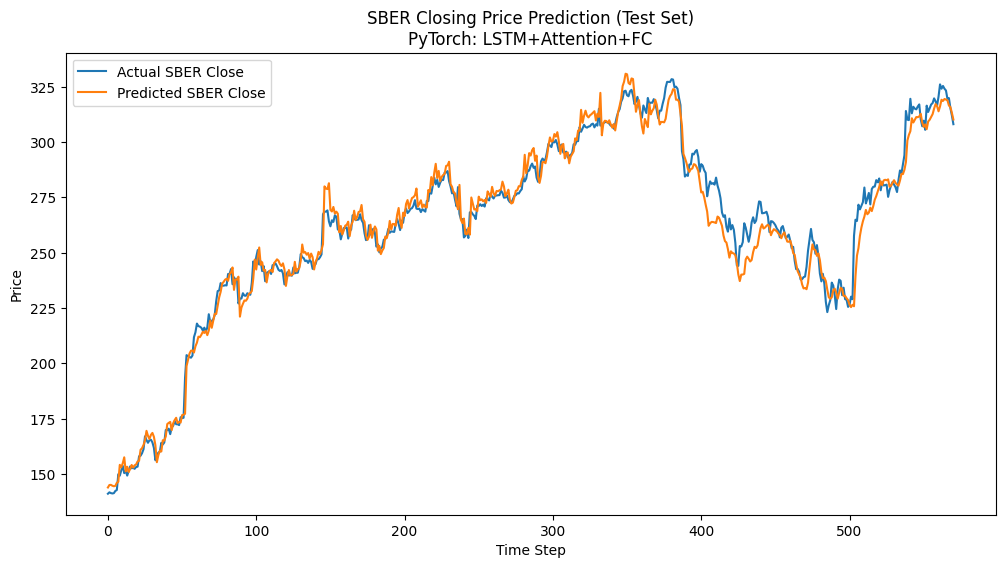

In [9]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna

# ============================================================
# 1. Функции для загрузки данных и вычисления индикаторов
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_sma(series: pd.Series, window: int = 14) -> pd.Series:
    return series.rolling(window=window).mean()

# ============================================================
# 2. Функции для загрузки и кэширования сырых данных
# ============================================================
def load_raw_data(cache_file="raw_moex_data.pkl"):
    """
    Загружает данные с MOEX или из кэша, если файл существует.
    """
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER", "OPEN": "OPEN_SBER",
                            "HIGH": "HIGH_SBER", "LOW": "LOW_SBER", "VOLUME": "VOL_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                        .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

# ============================================================
# 3. Подготовка данных для обучения (без повторной загрузки)
# ============================================================
def prepare_data(raw_df):
    # Разбивка на train/test по времени (80% для тренировки)
    total_len = len(raw_df)
    train_end = int(0.8 * total_len)
    train_df = raw_df.iloc[:train_end].copy()
    test_df  = raw_df.iloc[train_end:].copy()
    
    # Вычисляем индикаторы отдельно для train и test (без утечки)
    train_df["RSI_SBER"] = compute_rsi(train_df["CLOSE_SBER"], period=14)
    train_df["SMA_SBER"] = compute_sma(train_df["CLOSE_SBER"], window=14)
    test_df["RSI_SBER"] = compute_rsi(test_df["CLOSE_SBER"], period=14)
    test_df["SMA_SBER"] = compute_sma(test_df["CLOSE_SBER"], window=14)
    
    train_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    test_df.dropna(subset=["RSI_SBER", "SMA_SBER"], inplace=True)
    train_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)
    
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER", "SMA_SBER"]
    target_col = "CLOSE_SBER"
    
    train_data = train_df[features].values.astype(float)
    test_data  = test_df[features].values.astype(float)
    train_targets = train_df[[target_col]].values.astype(float)
    test_targets  = test_df[[target_col]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.float32))
    
    return train_dataset, test_dataset, scaler_y, seq_length, len(features)

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# 4. Определение модели на PyTorch
# ============================================================
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha
        context = torch.sum(context, dim=1)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ============================================================
# 5. Оптимизация гиперпараметров с помощью Optuna
# ============================================================
def objective(trial):
    # Используем глобальные кэшированные данные
    raw_df = load_raw_data()
    train_dataset, test_dataset, _, seq_length, num_features = prepare_data(raw_df)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    lstm_units = trial.suggest_int("lstm_units", 50, 400)
    fc_units   = trial.suggest_int("fc_units", 32, 300)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    device = torch.device("mps" if torch.backends.mps.is_available() 
                          else "cuda" if torch.cuda.is_available() else "cpu")
    model = PricePredictionModel(seq_length, num_features, output_dim=1,
                                 lstm_units=lstm_units, fc_units=fc_units, dropout_rate=dropout_rate)
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 5
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    return best_val_loss

# ============================================================
# 6. Финальное обучение модели с лучшими гиперпараметрами
# ============================================================
def train_final_model(best_params):
    raw_df = load_raw_data()
    train_dataset, test_dataset, scaler_y, seq_length, num_features = prepare_data(raw_df)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    device = torch.device("mps" if torch.backends.mps.is_available() 
                          else "cuda" if torch.cuda.is_available() else "cpu")
    
    model = PricePredictionModel(seq_length, num_features, output_dim=1,
                                 lstm_units=best_params["lstm_units"],
                                 fc_units=best_params["fc_units"],
                                 dropout_rate=best_params["dropout_rate"])
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    num_epochs = 40
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    model.load_state_dict(best_model_state)
    
    model.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"Метрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM+Attention+FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

# ============================================================
# 7. Запуск Optuna и финальное обучение
# ============================================================
if __name__ == "__main__":
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)  # Увеличьте число испытаний при необходимости
    print("Best trial:")
    trial = study.best_trial
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    print("\nОбучаем финальную модель с лучшими гиперпараметрами...")
    train_final_model(trial.params)


In [11]:
import torch
import pickle

# Предположим, что у вас есть обученная модель, например, model_pt,
# а также масштабировщики scaler_X и scaler_y, используемые для масштабирования данных

# Сохраняем состояние модели
torch.save(model_pt.state_dict(), "sber_model_state.pth")

# Сохраняем масштабировщики с помощью pickle
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)
with open("scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

print("Модель и масштабировщики успешно сохранены.")


Модель и масштабировщики успешно сохранены.
